In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2

from PIL import Image
# model Support Vector Machine
from sklearn.svm import SVC, LinearSVC
# funkcje do generowania przykładowych zbiorów danych
from sklearn.datasets import make_blobs, make_moons, make_circles
# algorytm PCA (do redukcji wymiarów danych)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# pozwala łączyć kilka kroków przetwarzania danych w jeden pipelin
from sklearn.pipeline import make_pipeline
# funkcja do mierzenia dokładności modelu
from sklearn.metrics import accuracy_score

### Wczytanie obrazów dla SVM/PCA

W tej funkcji obrazy są wczytywane z folderów klas. Obraz jest zamieniany do przestrzeni kolorów LAB i skalowany do rozmiaru `96 × 96`. Następnie obraz jest spłaszczany do jednego długiego wektora, ponieważ SVM i PCA nie pracują bezpośrednio na obrazie jako macierzy pikseli, tylko na wektorach cech.

Dodatkowo do danych dodawane są obrócone wersje obrazów. Jest to prosta augmentacja, która zwiększa liczbę przykładów treningowych.


In [3]:
def load_images(folder, size=(96, 96)):
    X = []
    y = []
    
    #tworzymy liste klas
    class_names = sorted(os.listdir(folder))

    #kazdemu gatunkowi przypisujemy numer
    for label, class_name in enumerate(class_names):
        class_path = os.path.join(folder, class_name)
        

        for filename in os.listdir(class_path):
            file_path = os.path.join(class_path, filename)
            
            img = cv2.imread(file_path)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
            #img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
            #img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, size)

            #obraz->macierz->wektor
            X.append(np.array(img).flatten())
            y.append(label)
            
            rotated = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
            X.append(rotated.flatten())
            y.append(label)
            
            rotated = cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)
            X.append(rotated.flatten())
            y.append(label)
            
    return np.array(X), np.array(y), class_names

In [4]:
X_train, y_train, class_names = load_images("data/Train_Test_Valid/Train")
X_test, y_test, class_names = load_images("data/Train_Test_Valid/test")
print(X_train.shape)
print(y_train.shape)

(2700, 27648)
(2700,)


Klasy: ['Moon_jellyfish', 'barrel_jellyfish', 'blue_jellyfish', 'compass_jellyfish', 'lions_mane_jellyfish', 'mauve_stinger_jellyfish']
X_train shape: (2700, 27648)
y_train shape: (2700,)


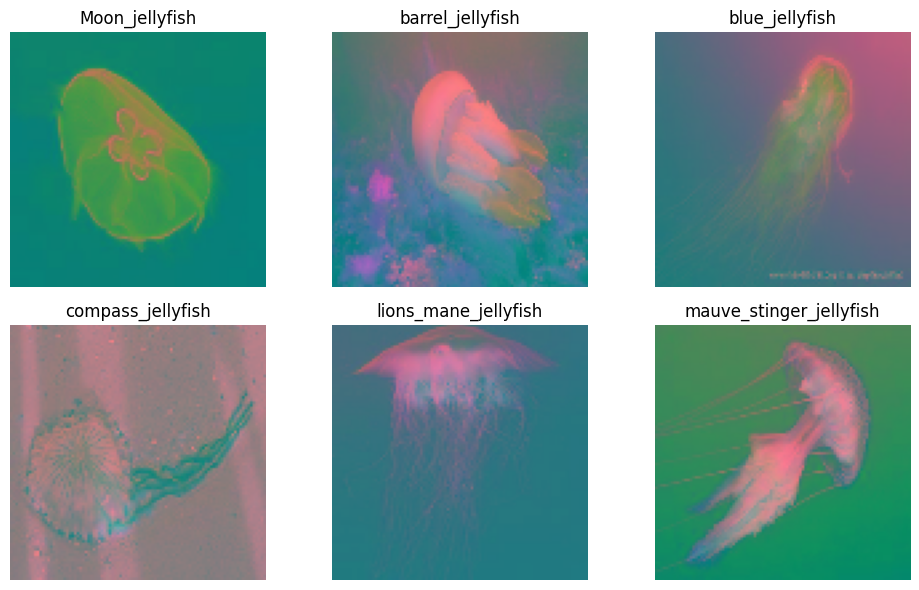

In [5]:
print("Klasy:", class_names)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
#900 obrazow, 9216cech

fig, ax = plt.subplots(2, 3, figsize=(10, 6))
for label, axi in enumerate(ax.flat):
    idx = np.where(y_train == label)[0][0]   # pierwszy obraz z danej klasy
    axi.imshow(X_train[idx].reshape(96, 96, 3))
    axi.set_title(class_names[label])
    axi.axis("off")

plt.tight_layout()
plt.show()

In [6]:
#spr

from collections import Counter

counts = Counter(y_train)

for label, count in counts.items():
    print(label, ":", count)

0 : 450
1 : 450
2 : 450
3 : 450
4 : 450
5 : 450


### PCA
PCA jest tutaj etapem redukcji wymiaru. Zachowuje najważniejsze kierunki zmienności danych, a odrzuca część mniej istotnych szczegółów. Taka idea jest powiązana z SVD, gdzie dane można opisać przez najważniejsze składowe zamiast przez wszystkie oryginalne wartości.


In [7]:
model = make_pipeline(
    StandardScaler(),
    PCA(n_components=100, whiten=True, svd_solver='randomized', random_state=42),
    SVC(kernel='rbf', class_weight='balanced')
)

### Dobór parametrów SVM

SVM ma parametry, które wpływają na sposób oddzielania klas. Najlepsze parametry są wybierane na podstawie walidacji krzyżowej. Oznacza to, że model jest kilka razy trenowany i sprawdzany na różnych częściach danych treningowych, a potem wybierana jest kombinacja, która działała najlepiej.


In [8]:
from sklearn.model_selection import GridSearchCV

#szukamy najlepszych parametrów do modelu
param_grid = {
    'svc__C': [1, 2, 4],
    'svc__gamma': ['scale', 0.0005, 0.005]
}

grid = GridSearchCV(model, param_grid)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'svc__C': 4, 'svc__gamma': 'scale'}


In [9]:
model = grid.best_estimator_
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Accuracy [%]:", acc * 100)

Accuracy [%]: 60.0


Model PCA + SVM osiągnął accuracy około 60% na zbiorze testowym. Oznacza to, że poprawnie sklasyfikował większość obrazów testowych.

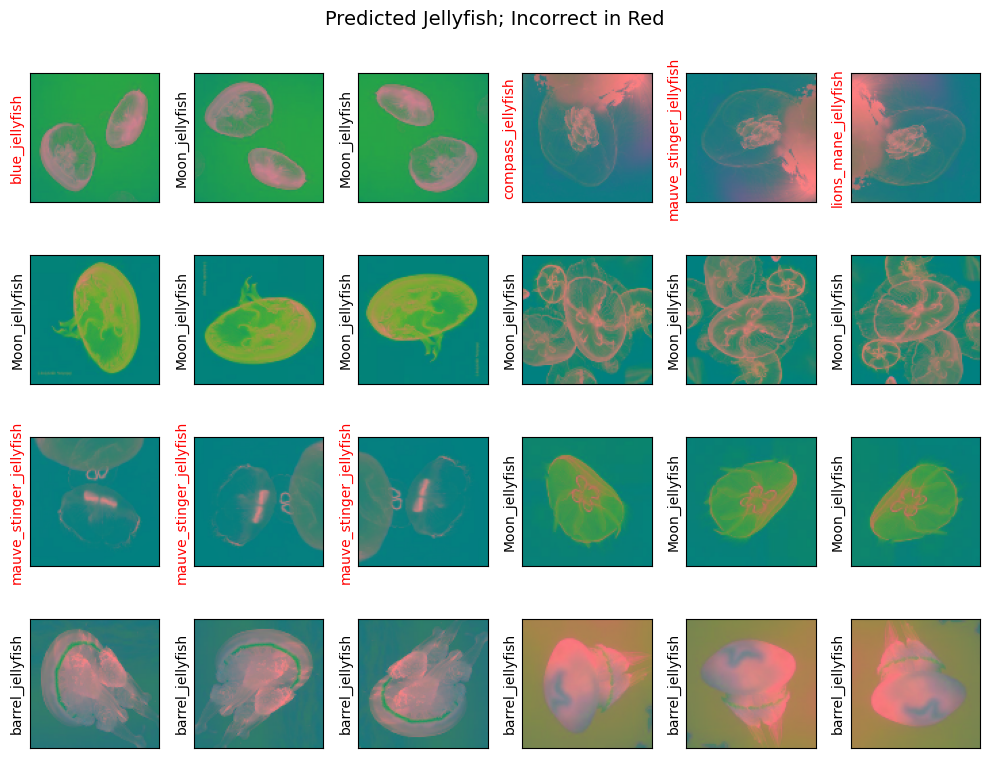

In [10]:
fig, ax = plt.subplots(4, 6, figsize=(10, 8))
for i, axi in enumerate(ax.flat):
    axi.imshow(X_test[i].reshape(96, 96, 3), cmap='gray')
    axi.set(xticks=[], yticks=[])

    axi.set_ylabel(
        class_names[y_pred[i]],
        color='black' if y_pred[i] == y_test[i] else 'red'
    )

fig.suptitle('Predicted Jellyfish; Incorrect in Red', size=14)
plt.tight_layout()
plt.show()

In [11]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred,
                            target_names=class_names))

                         precision    recall  f1-score   support

         Moon_jellyfish       0.61      0.61      0.61        18
       barrel_jellyfish       0.60      0.80      0.69        15
         blue_jellyfish       0.78      0.33      0.47        21
      compass_jellyfish       0.56      0.71      0.62        21
   lions_mane_jellyfish       0.60      0.75      0.67        24
mauve_stinger_jellyfish       0.56      0.43      0.49        21

               accuracy                           0.60       120
              macro avg       0.62      0.61      0.59       120
           weighted avg       0.62      0.60      0.59       120



## CNN - klasyfikacja meduz

W tej części używam prostego CNN zaimplementowanego w NumPy.  
W metodzie SVM/PCA obraz był od razu zamieniany na długi wektor. CNN działa inaczej, obraz zostaje w postaci macierzy pikseli. Najpierw patrzy na małe fragmenty obrazu, np. krawędzie, kontury i lokalne wzory, a dopiero później podejmuje decyzję o klasie.


### Przygotowanie obrazów dla CNN

Funkcja wczytuje obrazy tak samo jak wcześniej: zmienia przestrzeń kolorów na LAB i skaluje obraz do rozmiaru `96 × 96`.
Obrazy są normalizowane do zakresu `[0, 1]`, żeby wartości pikseli były małe i wygodne dla modelu. Augmentację, czyli sztuczne powiększenie danych przez rotacje, stosuję tylko dla zbioru treningowego.


In [22]:
def load_images_cnn(folder, size=(96, 96), augment=False):
    X, y = [], []
    class_names = sorted(os.listdir(folder))

    for label, class_name in enumerate(class_names):
        class_path = os.path.join(folder, class_name)

        if not os.path.isdir(class_path):
            continue

        for filename in os.listdir(class_path):
            file_path = os.path.join(class_path, filename)

            img = cv2.imread(file_path)
            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
            img = cv2.resize(img, size)

            X.append(img)
            y.append(label)

            # zwiększanie danych tylko dla zbioru treningowego
            if augment:
                X.append(cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE))
                y.append(label)

                X.append(cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE))
                y.append(label)

    X = np.array(X, dtype=np.float32) / 255.0
    y = np.array(y)

    return X, y, class_names

### Prosty CNN zaimplementowany w NumPy

Poniższa klasa zawiera minimalną implementację sieci CNN bez użycia gotowych bibliotek typu TensorFlow lub PyTorch.

Najpierw filtr konwolucyjny przesuwa się po obrazie i wykrywa lokalne cechy. Następnie ReLU zostawia tylko dodatnie odpowiedzi, a max pooling zmniejsza rozmiar danych, zachowując najsilniejsze sygnały. Na końcu warstwa dense zamienia wyuczone cechy na wynik klasyfikacji dla każdej klasy meduz.


In [23]:
class TinyNumPyCNN:
    # Minimal CNN implemented directly in NumPy.
    # Architecture:
    # input -> conv 3x3 -> ReLU -> 2x2 maxpool -> dense -> softmax.

    def __init__(self, image_shape=(96, 96), n_filters=8, n_classes=6, seed=42):
        self.image_height, self.image_width = image_shape
        self.n_filters = n_filters
        self.n_classes = n_classes

        if self.image_height % 2 != 0 or self.image_width % 2 != 0:
            raise ValueError("This simple demo assumes even image height and width.")

        pooled_size = n_filters * (self.image_height // 2) * (self.image_width // 2)

        rng = np.random.default_rng(seed)

        # Convolution weights: (filters, channels, kernel height, kernel width)
        self.Wc = 0.5 * rng.normal(
            0.0,
            np.sqrt(2.0 / 9.0),
            size=(n_filters, 1, 3, 3),
        ).astype(np.float32)

        self.bc = np.zeros(n_filters, dtype=np.float32)

        # Dense layer weights
        self.Wd = 0.5 * rng.normal(
            0.0,
            np.sqrt(2.0 / pooled_size),
            size=(pooled_size, n_classes),
        ).astype(np.float32)

        self.bd = np.zeros(n_classes, dtype=np.float32)

        self.velocity = {
            "Wc": np.zeros_like(self.Wc),
            "bc": np.zeros_like(self.bc),
            "Wd": np.zeros_like(self.Wd),
            "bd": np.zeros_like(self.bd),
        }

    def parameters(self):
        return {
            "Wc": self.Wc,
            "bc": self.bc,
            "Wd": self.Wd,
            "bd": self.bd,
        }

    def forward(self, X):
        B, C, H, W = X.shape

        if C != 1:
            raise ValueError("This tutorial CNN expects grayscale images with one channel.")

        if H != self.image_height or W != self.image_width:
            raise ValueError(
                f"Expected images of shape {(self.image_height, self.image_width)}, "
                f"but received {(H, W)}."
            )

        K = self.n_filters

        # Same padding for a 3x3 filter.
        X_pad = np.pad(
            X,
            pad_width=((0, 0), (0, 0), (1, 1), (1, 1)),
            mode="constant",
        )

        # Convolution/cross-correlation.
        Z = np.zeros((B, K, H, W), dtype=np.float32)

        for r in range(3):
            for s in range(3):
                image_patch = X_pad[:, 0, r:r + H, s:s + W]
                filter_weights = self.Wc[:, 0, r, s]
                Z += image_patch[:, None, :, :] * filter_weights[None, :, None, None]

        Z += self.bc[None, :, None, None]

        # ReLU.
        A = np.maximum(Z, 0.0)

        # 2x2 max pooling.
        A_blocks = A.reshape(B, K, H // 2, 2, W // 2, 2)
        P = A_blocks.max(axis=(3, 5))

        # Dense classifier.
        F = P.reshape(B, -1)
        logits = F @ self.Wd + self.bd

        cache = (X, X_pad, Z, A, A_blocks, P, F)
        return logits, cache

    @staticmethod
    def softmax(logits):
        shifted = logits - logits.max(axis=1, keepdims=True)
        exp_values = np.exp(shifted)
        return exp_values / exp_values.sum(axis=1, keepdims=True)

    def predict_proba(self, X):
        logits, _ = self.forward(X)
        return self.softmax(logits)

    def predict(self, X):
        return self.predict_proba(X).argmax(axis=1)

    def loss_and_accuracy(self, X, y):
        logits, _ = self.forward(X)
        probs = self.softmax(logits)

        loss = -np.log(probs[np.arange(len(y)), y] + 1e-12).mean()
        predictions = probs.argmax(axis=1)
        accuracy = np.mean(predictions == y)

        return float(loss), float(accuracy)

    def train_step(self, X_batch, y_batch, lr=0.05, momentum=0.9, weight_decay=1e-4):
        B = X_batch.shape[0]
        H = self.image_height
        W = self.image_width
        K = self.n_filters

        logits, cache = self.forward(X_batch)
        X, X_pad, Z, A, A_blocks, P, F = cache

        probs = self.softmax(logits)

        loss = -np.log(probs[np.arange(B), y_batch] + 1e-12).mean()

        # Gradient of cross entropy with softmax.
        dlogits = probs.copy()
        dlogits[np.arange(B), y_batch] -= 1.0
        dlogits /= B

        # Dense layer gradients.
        dWd = F.T @ dlogits + weight_decay * self.Wd
        dbd = dlogits.sum(axis=0)
        dF = dlogits @ self.Wd.T

        # Backpropagate through max pooling.
        dP = dF.reshape(B, K, H // 2, W // 2)

        max_values = P[:, :, :, None, :, None]
        pool_mask = (A_blocks == max_values)

        # If several entries are tied maxima, distribute the gradient equally.
        counts = pool_mask.sum(axis=(3, 5), keepdims=True)
        dA_blocks = pool_mask * (dP[:, :, :, None, :, None] / counts)
        dA = dA_blocks.reshape(B, K, H, W)

        # Backpropagate through ReLU.
        dZ = dA * (Z > 0)

        # Convolution gradients.
        dWc = np.zeros_like(self.Wc)
        dbc = dZ.sum(axis=(0, 2, 3))

        for r in range(3):
            for s in range(3):
                image_patch = X_pad[:, 0, r:r + H, s:s + W]
                dWc[:, 0, r, s] = (
                    dZ * image_patch[:, None, :, :]
                ).sum(axis=(0, 2, 3))

        dWc += weight_decay * self.Wc

        gradients = {
            "Wc": dWc,
            "bc": dbc,
            "Wd": dWd,
            "bd": dbd,
        }

        # Momentum SGD update.
        for name, param in self.parameters().items():
            self.velocity[name] = momentum * self.velocity[name] - lr * gradients[name]
            param += self.velocity[name]

        predictions = probs.argmax(axis=1)
        accuracy = np.mean(predictions == y_batch)

        return float(loss), float(accuracy)

### Wczytanie zbioru treningowego i testowego
Na tym etapie obrazy nadal mają trzy kanały LAB. W kolejnym kroku wybieram jeden kanał, ponieważ używana implementacja CNN działa na obrazach jednokanałowych. Wybieram kanał L, czyli jasność obrazu. Ten kanał zawiera informację o kształtach, konturach i kontraście.

In [24]:
X_train_cnn, y_train_cnn, class_names_cnn = load_images_cnn(
    "data/Train_Test_Valid/Train",
    augment=True
)
X_test_cnn, y_test_cnn, class_names_test = load_images_cnn(
    "data/Train_Test_Valid/test",
    augment=False
)
print("Klasy:", class_names_cnn)
print("Train:", X_train_cnn.shape, y_train_cnn.shape)
print("Test:", X_test_cnn.shape, y_test_cnn.shape)

Klasy: ['Moon_jellyfish', 'barrel_jellyfish', 'blue_jellyfish', 'compass_jellyfish', 'lions_mane_jellyfish', 'mauve_stinger_jellyfish']
Train: (2700, 96, 96, 3) (2700,)
Test: (40, 96, 96, 3) (40,)


In [25]:
channel = 0  # 0=L jasność, 1=A zielony-czerwony, 2=B niebieski-żółty

X_train_gray = X_train_cnn[:, :, :, channel][:, None, :, :]
X_test_gray = X_test_cnn[:, :, :, channel][:, None, :, :]

print("Train:", X_train_gray.shape)
print("Test:", X_test_gray.shape)

Train: (2700, 1, 96, 96)
Test: (40, 1, 96, 96)


### Podział danych na trening i walidację

Zbiór treningowy służy do uczenia modelu.
Zbiór walidacyjny pozwala sprawdzić, czy model poprawia się także na danych, których nie widzi bezpośrednio podczas aktualizacji wag.

In [26]:
from sklearn.model_selection import train_test_split

X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_train_gray,
    y_train_cnn,
    test_size=0.2,
    random_state=42,
    stratify=y_train_cnn
)

print("Train part:", X_train_part.shape, y_train_part.shape)
print("Validation:", X_val.shape, y_val.shape)

Train part: (2160, 1, 96, 96) (2160,)
Validation: (540, 1, 96, 96) (540,)


### Utworzenie modelu CNN

Prosty model CNN dla obrazów `96 × 96` i sześciu klas meduz. Model ma 8 filtrów konwolucyjnych. Każdy filtr uczy się wykrywać lokalne wzorce w obrazie.
Przed treningiem sprawdzam wynik początkowy. Dla sześciu klas losowe zgadywanie daje około `1/6`.


In [27]:
num_classes = len(class_names_cnn)

cnn = TinyNumPyCNN(
    image_shape=(96, 96),
    n_filters=8,
    n_classes=num_classes,
    seed=42
)

initial_loss, initial_acc = cnn.loss_and_accuracy(X_val, y_val)

print("Validation accuracy przed treningiem:", initial_acc)

Validation accuracy przed treningiem: 0.1962962962962963


### Batches

Model nie uczy się na wszystkich obrazach naraz. Dane są dzielone na mniejsze paczki. Dzięki temu po każdej małej grupie obrazów model może zaktualizować swoje wagi.


In [28]:
def get_batches(X, y, batch_size=16, seed=42):
    rng = np.random.default_rng(seed)
    indices = rng.permutation(len(X))

    for start in range(0, len(X), batch_size):
        batch_indices = indices[start:start + batch_size]
        yield X[batch_indices], y[batch_indices]

### Trening CNN

W czasie treningu model przechodzi przez dane kilka razy. Na początku używam trochę większego learning rate, żeby model szybciej zaczął się uczyć. Po trzech zmniejszam learning rate, żeby aktualizacje wag były spokojniejsze. Zapisuję loss i accuracy dla treningu oraz walidacji.


In [31]:
EPOCHS = 10
BATCH_SIZE = 16

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

best_val_acc = 0
best_params = None
best_epoch = 0

for epoch in range(EPOCHS):
    lr = 0.008 if epoch < 3 else 0.003
    losses, accs = [], []

    for X_batch, y_batch in get_batches(
        X_train_part,
        y_train_part,
        batch_size=BATCH_SIZE,
        seed=42 + epoch
    ):
        loss, acc = cnn.train_step(X_batch, y_batch, lr=lr)
        losses.append(loss)
        accs.append(acc)

    train_loss = np.mean(losses)
    train_acc = np.mean(accs)
    val_loss, val_acc = cnn.loss_and_accuracy(X_val, y_val)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        best_params = {name: param.copy() for name, param in cnn.parameters().items()}

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"train acc: {train_acc:.3f} | "
        f"val acc: {val_acc:.3f}"
    )


Epoch 1/10 | train acc: 0.762 | val acc: 0.424
Epoch 2/10 | train acc: 0.797 | val acc: 0.437
Epoch 3/10 | train acc: 0.855 | val acc: 0.446
Epoch 4/10 | train acc: 0.927 | val acc: 0.448
Epoch 5/10 | train acc: 0.960 | val acc: 0.444
Epoch 6/10 | train acc: 0.968 | val acc: 0.456
Epoch 7/10 | train acc: 0.976 | val acc: 0.437
Epoch 8/10 | train acc: 0.976 | val acc: 0.457
Epoch 9/10 | train acc: 0.988 | val acc: 0.461
Epoch 10/10 | train acc: 0.986 | val acc: 0.461


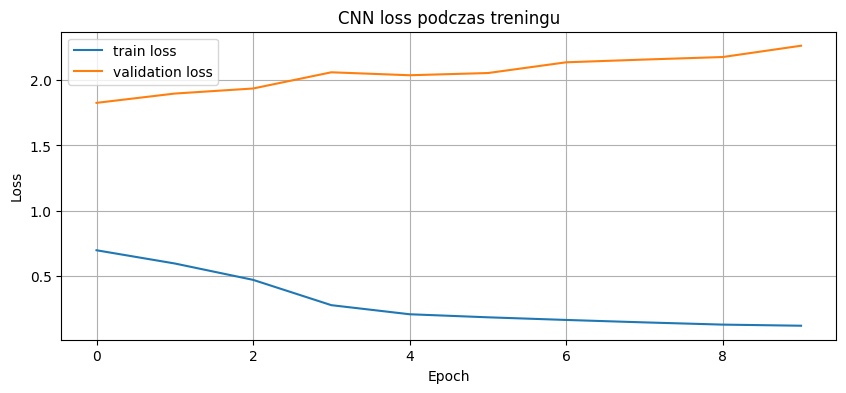

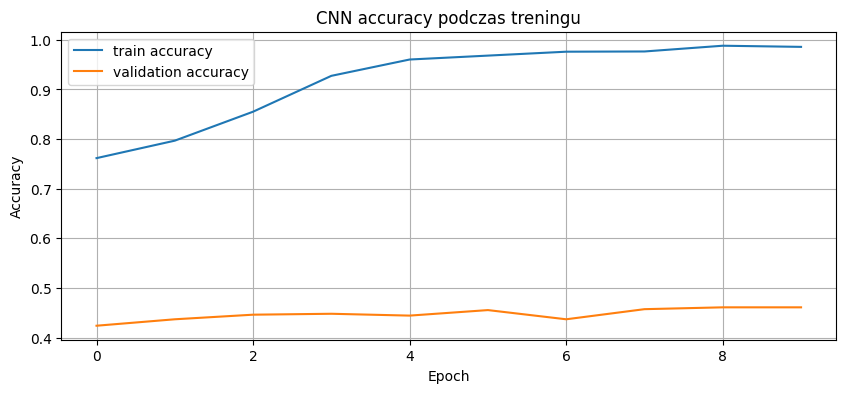

In [32]:
plt.figure(figsize=(10, 4))

plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN loss podczas treningu")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))

plt.plot(history["train_acc"], label="train accuracy")
plt.plot(history["val_acc"], label="validation accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN accuracy podczas treningu")
plt.legend()
plt.grid(True)
plt.show()

In [33]:
test_loss, test_acc = cnn.loss_and_accuracy(X_test_gray, y_test_cnn)

print("Test loss:", test_loss)
print("Accuracy [%]:", test_acc * 100)

Test loss: 2.2415459156036377
Accuracy [%]: 45.0


In [34]:
from sklearn.metrics import classification_report

y_pred_test = cnn.predict(X_test_gray)

print(classification_report(
    y_test_cnn,
    y_pred_test,
    target_names=class_names_cnn,
    zero_division=0
))

                         precision    recall  f1-score   support

         Moon_jellyfish       0.50      0.50      0.50         6
       barrel_jellyfish       0.60      0.60      0.60         5
         blue_jellyfish       0.50      0.57      0.53         7
      compass_jellyfish       0.50      0.43      0.46         7
   lions_mane_jellyfish       0.30      0.38      0.33         8
mauve_stinger_jellyfish       0.40      0.29      0.33         7

               accuracy                           0.45        40
              macro avg       0.47      0.46      0.46        40
           weighted avg       0.45      0.45      0.45        40



CNN uzyskał na zbiorze testowym accuracy równe `0.45`. Wynik jest wyraźnie lepszy niż losowe zgadywanie dla 6 klas, które wynosi około `0.167`.

Najlepiej rozpoznawane były klasy `barrel_jellyfish`, `Moon_jellyfish` i `blue_jellyfish`. Najsłabszy wynik pojawił się dla `lions_mane_jellyfish` i `mauve_stinger_jellyfish` , co może oznaczać, że jej cechy są podobne do innych klas albo model ma za mało informacji, korzystając tylko z jednego kanału LAB.
